# 17 - ARIMA/SARIMAX como baseline estadistico secuencial

Este notebook evalua un nivel intermedio de complejidad entre los baselines simples del notebook 15 y los modelos de deep learning como N-BEATS.

La pregunta experimental es:

```text
Un modelo estadistico secuencial clasico puede acercarse al desempeno de Ridge-ARX o N-BEATS para predecir el nivel del Mburicao a 10, 20 y 30 minutos?
```

Se trabaja con los mismos dos segmentos temporales usados en los experimentos anteriores:

- segmento 2021;
- segmento 2025.

Ambos segmentos se tratan de forma independiente. No se concatenan, porque entre 2022 y 2025 no hay observaciones y unirlos produciria una continuidad temporal artificial.


## Justificacion metodologica

ARIMA y SARIMAX son modelos estadisticos clasicos para series temporales. Son utiles como punto intermedio porque incorporan memoria temporal de manera explicita, pero son mas simples e interpretables que un modelo de deep learning.

En este notebook se prueban dos familias:

1. **ARIMA**, modelo univariado que usa solo la historia del nivel.
2. **SARIMAX con variables exogenas conocidas en el origen de prediccion**, que agrega informacion reciente de lluvia y cambios recientes del nivel.

ARIMA puro es una referencia importante, pero hidrologicamente limitada: si no recibe informacion de lluvia, solo puede extrapolar la dinamica autoregresiva del nivel. SARIMAX es mas coherente con el problema lluvia-nivel porque permite incluir forzantes exogenas.

Se evita usar lluvia futura observada como variable exogena, porque eso produciria fuga de informacion. Para predecir a 10, 20 y 30 minutos, las variables exogenas se construyen solo con informacion disponible hasta el origen de prediccion.


## Sobre el desbalance de eventos

Las series del Mburicao tienen muchos periodos de baja variabilidad y pocos eventos de crecida. Esto puede favorecer metricas globales aparentemente buenas, incluso si el modelo falla durante los picos.

Por eso, igual que en el notebook 15, la evaluacion se divide en:

- metricas globales;
- metricas por segmento;
- metricas por lead time;
- metricas en condiciones criticas:
  - precipitacion mayor que cero;
  - lluvia acumulada de 1 hora alta;
  - nivel en percentil 90 o superior;
  - delta positivo alto.

La utilidad para alerta temprana depende especialmente del desempeno en estas condiciones criticas.


In [4]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\moran\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\moran\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\moran\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\moran\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\moran\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")


## Configuracion experimental

Se usa el mismo protocolo general del notebook 15:

- frecuencia regular de 10 minutos;
- horizonte maximo de 3 pasos;
- predicciones a 10, 20 y 30 minutos;
- split cronologico 70/15/15 por segmento.

La seleccion de ordenes ARIMA/SARIMAX se hace con validacion. Las metricas finales se calculan sobre test.

No se activa una estacionalidad diaria `s=144` por defecto. Aunque los datos tienen frecuencia de 10 minutos, el fenomeno de interes no parece dominado por una estacionalidad regular, sino por eventos de lluvia. Una SARIMA diaria tambien seria mas costosa y menos estable con eventos extremos escasos.


In [6]:
TIME_COL = "Time"
TARGET_COL = "Nivel"
RAIN_COL = "Precipitacion"

FREQ = "10min"
FREQ_DELTA = pd.Timedelta(FREQ)
STEPS_PER_HOUR = 6
FORECAST_HORIZON = 3
EVAL_STRIDE = 1

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15

# Ordenes pequenas para mantener el experimento interpretable y computacionalmente razonable.
ARIMA_CANDIDATE_ORDERS = [
    (1, 0, 0),
    (2, 0, 1),
    (1, 1, 1),
]

SARIMAX_CANDIDATE_ORDERS = [
    (1, 0, 0),
    (2, 0, 1),
    (1, 1, 1),
]

SEASONAL_ORDER = (0, 0, 0, 0)
SARIMAX_MAXITER = 200

RANDOM_STATE = 42


## Rutas del proyecto

Esta celda replica la logica del notebook 15 para encontrar el proyecto y los CSV tanto en la maquina local como en JupyterHub.

No se usa `pathlib`, solamente `os`.


In [7]:
def resolve_project_dir():
    cwd = os.getcwd()
    candidates = [
        cwd,
        os.path.dirname(cwd),
        os.path.join(cwd, "Mburicao_Iberamia"),
        os.path.join(os.path.dirname(cwd), "Mburicao_Iberamia"),
        r"D:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia",
        "/data/students/federico.moran",
        "/data/students/federico.moran/notebooks",
    ]

    for candidate in candidates:
        if not candidate:
            continue
        if os.path.exists(os.path.join(candidate, "notebooks")) or os.path.exists(os.path.join(candidate, "data")):
            return os.path.abspath(candidate)

    return os.path.abspath(cwd)


PROJECT_DIR = resolve_project_dir()

FIGURES_DIR = os.path.join(PROJECT_DIR, "figures", "17_arima_sarimax_baselines")
REPORTS_DIR = os.path.join(PROJECT_DIR, "reports", "17_arima_sarimax_baselines")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)


def find_csv(filename):
    candidates = [
        os.path.join(PROJECT_DIR, "data", "processed", "datos_lluvia_nivel", filename),
        os.path.join(PROJECT_DIR, "datasets", "datos_lluvia_nivel", filename),
        os.path.join(os.path.dirname(PROJECT_DIR), "datasets", "datos_lluvia_nivel", filename),
        os.path.join("/data/students/federico.moran", "datasets", "datos_lluvia_nivel", filename),
        os.path.join("/data/students/federico.moran", "notebooks", "datasets", "datos_lluvia_nivel", filename),
    ]

    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate

    raise FileNotFoundError("No se encontro el archivo: " + filename + "\nCandidatos:\n" + "\n".join(candidates))


CSV_PATHS = {
    "2021": find_csv("Mburicao_2021.csv"),
    "2025": find_csv("Mburicao_2025.csv"),
}

print("PROJECT_DIR:", PROJECT_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("REPORTS_DIR:", REPORTS_DIR)
print("CSV encontrados:")
for segment_name, path in CSV_PATHS.items():
    print(segment_name, "->", path)


PROJECT_DIR: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia
FIGURES_DIR: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\figures\17_arima_sarimax_baselines
REPORTS_DIR: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\17_arima_sarimax_baselines
CSV encontrados:
2021 -> d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\data\processed\datos_lluvia_nivel\Mburicao_2021.csv
2025 -> d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\data\processed\datos_lluvia_nivel\Mburicao_2025.csv


## Carga y preprocesamiento por segmento

Cada archivo se carga y regulariza por separado a 10 minutos. El nivel se interpola temporalmente y la precipitacion faltante se interpreta como cero luego del reindexado.

Este preprocesamiento mantiene la misma logica del notebook 15 para que los resultados sean comparables.


In [8]:
def load_segment(csv_path, segment_name):
    df = pd.read_csv(csv_path)

    required_columns = {TIME_COL, TARGET_COL, RAIN_COL}
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f"Faltan columnas requeridas en {csv_path}: {sorted(missing_columns)}")

    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df = df.dropna(subset=[TIME_COL])
    df = df.sort_values(TIME_COL)
    df = df.set_index(TIME_COL)
    df = df[~df.index.duplicated(keep="first")]

    df = df[[TARGET_COL, RAIN_COL]].copy()
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    df[RAIN_COL] = pd.to_numeric(df[RAIN_COL], errors="coerce")

    df = df.asfreq(FREQ)
    df[TARGET_COL] = df[TARGET_COL].interpolate(method="time").ffill().bfill()
    df[RAIN_COL] = df[RAIN_COL].fillna(0.0)
    df["segmento"] = segment_name

    return df


segments = {}
for segment_name, csv_path in CSV_PATHS.items():
    segments[segment_name] = load_segment(csv_path, segment_name)

segment_names = list(segments.keys())

summary_rows = []
for segment_name, df_segment in segments.items():
    summary_rows.append({
        "segmento": segment_name,
        "filas": len(df_segment),
        "inicio": df_segment.index.min(),
        "fin": df_segment.index.max(),
        "freq_inferida": pd.infer_freq(df_segment.index),
        "nivel_min": df_segment[TARGET_COL].min(),
        "nivel_max": df_segment[TARGET_COL].max(),
        "lluvia_total": df_segment[RAIN_COL].sum(),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_path = os.path.join(REPORTS_DIR, "17_dataset_resumen.csv")
summary_df.to_csv(summary_path, index=False)
print("Resumen guardado en:", summary_path)


,segmento,filas,inicio,fin,freq_inferida,nivel_min,nivel_max,lluvia_total
0,2021,42220,2021-06-12 12:00:00,2022-04-01 16:30:00,10min,0.030263,3.746,741.6
1,2025,29055,2025-08-27 15:10:00,2026-03-17 09:30:00,10min,0.400000,3.300,317.2


Resumen guardado en: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\17_arima_sarimax_baselines\17_dataset_resumen.csv


## Split train / validation / test

El split se calcula de manera cronologica en cada segmento:

```text
70% train
15% validation
15% test
```

La validacion se usa para seleccionar el orden ARIMA/SARIMAX. El test queda reservado para las metricas finales.


In [9]:
split_info = {}

for segment_name in segment_names:
    df_segment = segments[segment_name]
    n = len(df_segment)

    train_end_position = int(n * TRAIN_FRACTION)
    val_end_position = int(n * (TRAIN_FRACTION + VAL_FRACTION))

    min_history = max(24, FORECAST_HORIZON + 1)

    train_end_position = max(train_end_position, min_history + FORECAST_HORIZON + 1)
    val_end_position = max(val_end_position, train_end_position + FORECAST_HORIZON + 1)
    val_end_position = min(val_end_position, n - FORECAST_HORIZON - 1)

    train_end_time = df_segment.index[train_end_position]
    test_start_time = df_segment.index[val_end_position]

    split_info[segment_name] = {
        "train_end_position": train_end_position,
        "val_end_position": val_end_position,
        "test_start_position": val_end_position,
        "train_end_time": train_end_time,
        "test_start_time": test_start_time,
        "train_points": train_end_position,
        "val_points": val_end_position - train_end_position,
        "test_points": n - val_end_position,
    }

split_df = pd.DataFrame([
    {
        "segmento": segment_name,
        "train_end_position": info["train_end_position"],
        "val_end_position": info["val_end_position"],
        "train_end_time": info["train_end_time"],
        "test_start_time": info["test_start_time"],
        "train_points": info["train_points"],
        "val_points": info["val_points"],
        "test_points": info["test_points"],
    }
    for segment_name, info in split_info.items()
])

display(split_df)

split_path = os.path.join(REPORTS_DIR, "17_split_resumen.csv")
split_df.to_csv(split_path, index=False)
print("Split guardado en:", split_path)


,segmento,train_end_position,val_end_position,train_end_time,test_start_time,train_points,val_points,test_points
0,2021,29553,35887,2022-01-03 17:30:00,2022-02-16 17:10:00,29553,6334,6333
1,2025,20338,24696,2026-01-15 20:50:00,2026-02-15 03:10:00,20338,4358,4359


Split guardado en: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\17_arima_sarimax_baselines\17_split_resumen.csv


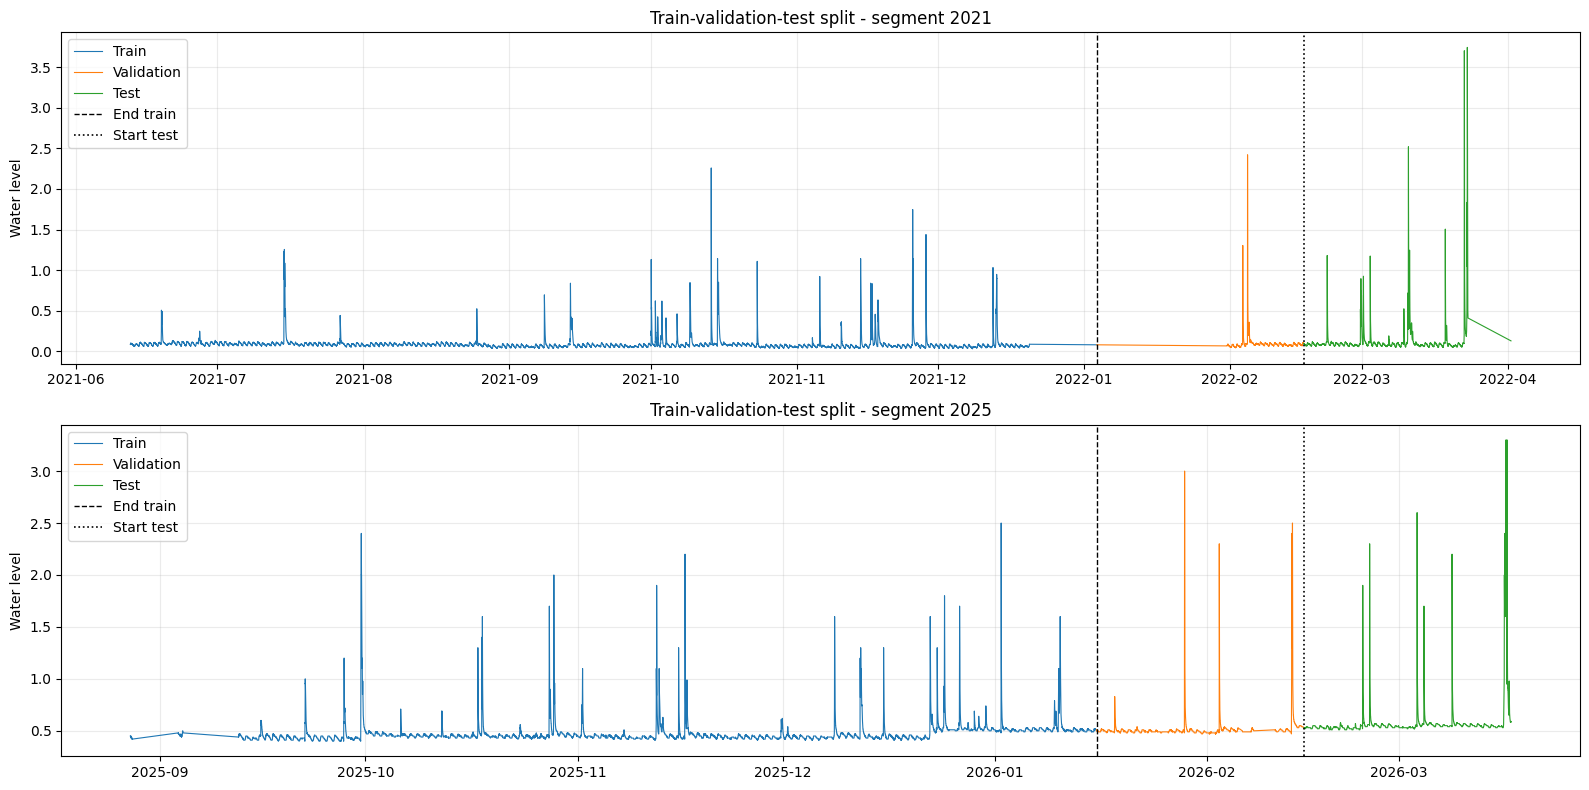

In [10]:
fig, axes = plt.subplots(len(segment_names), 1, figsize=(16, 4 * len(segment_names)), sharex=False)
if len(segment_names) == 1:
    axes = [axes]

for ax, segment_name in zip(axes, segment_names):
    df_segment = segments[segment_name]
    train_end_time = split_info[segment_name]["train_end_time"]
    test_start_time = split_info[segment_name]["test_start_time"]

    train_df = df_segment.loc[df_segment.index < train_end_time]
    val_df = df_segment.loc[(df_segment.index >= train_end_time) & (df_segment.index < test_start_time)]
    test_df = df_segment.loc[df_segment.index >= test_start_time]

    ax.plot(train_df.index, train_df[TARGET_COL], label="Train", color="tab:blue", linewidth=0.8)
    ax.plot(val_df.index, val_df[TARGET_COL], label="Validation", color="tab:orange", linewidth=0.8)
    ax.plot(test_df.index, test_df[TARGET_COL], label="Test", color="tab:green", linewidth=0.8)

    ax.axvline(train_end_time, color="black", linestyle="--", linewidth=1, label="End train")
    ax.axvline(test_start_time, color="black", linestyle=":", linewidth=1.2, label="Start test")

    ax.set_title(f"Train-validation-test split - segment {segment_name}")
    ax.set_ylabel("Water level")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "01_split_train_val_test_por_segmento.png"), dpi=180, bbox_inches="tight")
plt.show()


## Variables exogenas para SARIMAX

SARIMAX necesita variables exogenas alineadas con cada instante objetivo. Para evitar fuga de informacion, las variables exogenas en el instante `t` se calculan usando solo informacion disponible hasta `t-1`.

Se incluyen:

- lluvia del paso anterior;
- lluvia acumulada previa de 30 y 60 minutos;
- lluvia maxima previa de 60 minutos;
- delta de nivel del paso anterior;
- cambio acumulado de nivel previo de 30 minutos.

Durante una prediccion multi-step, estas variables se mantienen fijas en el valor conocido en el origen de prediccion. Esto es conservador: no se usa lluvia futura observada.


In [11]:
EXOG_COLS = [
    "lluvia_lag_10min",
    "lluvia_sum_30min_prev",
    "lluvia_sum_60min_prev",
    "lluvia_max_60min_prev",
    "delta_nivel_lag_10min",
    "delta_nivel_sum_30min_prev",
]


def build_known_exog(df_segment):
    y = df_segment[TARGET_COL].astype(float)
    rain = df_segment[RAIN_COL].astype(float)
    delta = y.diff()

    exog = pd.DataFrame(index=df_segment.index)
    exog["lluvia_lag_10min"] = rain.shift(1)
    exog["lluvia_sum_30min_prev"] = rain.shift(1).rolling(3, min_periods=1).sum()
    exog["lluvia_sum_60min_prev"] = rain.shift(1).rolling(6, min_periods=1).sum()
    exog["lluvia_max_60min_prev"] = rain.shift(1).rolling(6, min_periods=1).max()
    exog["delta_nivel_lag_10min"] = delta.shift(1)
    exog["delta_nivel_sum_30min_prev"] = delta.shift(1).rolling(3, min_periods=1).sum()
    exog = exog.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return exog[EXOG_COLS]


raw_exog_by_segment = {
    segment_name: build_known_exog(df_segment)
    for segment_name, df_segment in segments.items()
}

scaled_exog_by_segment = {}
exog_scalers = {}

for segment_name in segment_names:
    train_end_position = split_info[segment_name]["train_end_position"]
    train_exog = raw_exog_by_segment[segment_name].iloc[:train_end_position]
    mean = train_exog.mean()
    std = train_exog.std().replace(0, 1.0)

    exog_scalers[segment_name] = {"mean": mean, "std": std}
    scaled_exog_by_segment[segment_name] = (raw_exog_by_segment[segment_name] - mean) / std

display(raw_exog_by_segment["2021"].head())


,lluvia_lag_10min,lluvia_sum_30min_prev,lluvia_sum_60min_prev,lluvia_max_60min_prev,delta_nivel_lag_10min,delta_nivel_sum_30min_prev
Time,,,,,,
2021-06-12 12:00:00,0.0,0.0,0.0,0.0,0.000000,0.000000
2021-06-12 12:10:00,0.0,0.0,0.0,0.0,0.000000,0.000000
2021-06-12 12:20:00,0.0,0.0,0.0,0.0,0.000820,0.000820
2021-06-12 12:30:00,0.0,0.0,0.0,0.0,0.001944,0.002764
2021-06-12 12:40:00,0.0,0.0,0.0,0.0,0.006134,0.008899


## Utilidades de metricas y formato largo

Las predicciones se guardan en formato largo:

| columna | significado |
|---|---|
| `modelo` | ARIMA o SARIMAX seleccionado |
| `segmento` | 2021 o 2025 |
| `origin_time` | ultimo instante observado antes de predecir |
| `pred_time` | instante futuro predicho |
| `lead_minutes` | horizonte de prediccion en minutos |
| `pred` | valor predicho |
| `actual` | valor observado |

Este formato permite calcular metricas globales, por segmento, por lead time y por condicion critica.


In [12]:
EPS = 1e-8


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return {
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "MAPE (%)": np.nan,
            "sMAPE (%)": np.nan,
            "Bias": np.nan,
            "NSE": np.nan,
        }

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    if len(np.unique(y_true)) > 1:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan

    valid_mape = np.abs(y_true) > EPS
    if valid_mape.any():
        mape = np.mean(np.abs((y_true[valid_mape] - y_pred[valid_mape]) / y_true[valid_mape])) * 100
    else:
        mape = np.nan

    smape_denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid_smape = smape_denom > EPS
    if valid_smape.any():
        smape = np.mean(np.abs(y_true[valid_smape] - y_pred[valid_smape]) / smape_denom[valid_smape]) * 100
    else:
        smape = np.nan

    bias = np.mean(y_pred - y_true)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    nse = 1 - np.sum((y_true - y_pred) ** 2) / denominator if denominator > EPS else np.nan

    return {
        "n": len(y_true),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape,
        "sMAPE (%)": smape,
        "Bias": bias,
        "NSE": nse,
    }


def context_for_segment(segment_name):
    df_segment = segments[segment_name]
    context = df_segment[[TARGET_COL, RAIN_COL]].copy()
    context["lluvia_1h"] = context[RAIN_COL].rolling(STEPS_PER_HOUR, min_periods=1).sum()
    context["delta_nivel"] = context[TARGET_COL].diff()
    context = context.rename(columns={TARGET_COL: "actual"})
    context["pred_time"] = context.index
    return context


def enrich_prediction_rows(segment_name, model_name, rows):
    pred_df = pd.DataFrame(rows)
    if pred_df.empty:
        return pred_df

    context = context_for_segment(segment_name)

    pred_df["segmento"] = segment_name
    pred_df["modelo"] = model_name
    pred_df = pred_df.merge(
        context[["pred_time", "actual", RAIN_COL, "lluvia_1h", "delta_nivel"]],
        on="pred_time",
        how="left",
    )

    return pred_df.dropna(subset=["actual", "pred"]).reset_index(drop=True)


## Entrenamiento y prediccion rolling-origin

Los modelos estadisticos se ajustan inicialmente con el set de entrenamiento. Luego se generan predicciones en modo rolling-origin:

1. el modelo predice los siguientes 10, 20 y 30 minutos;
2. se registra el error;
3. se incorpora la siguiente observacion real al estado del modelo sin reestimar parametros (`refit=False`);
4. se avanza al siguiente origen.

Esto imita un uso operacional: cuando llega una nueva observacion, el modelo puede actualizar su estado interno antes de emitir la siguiente prediccion.


In [13]:
def order_to_label(order):
    return f"p{order[0]}_d{order[1]}_q{order[2]}"


def fit_sarimax_result(segment_name, order, use_exog):
    df_segment = segments[segment_name]
    train_end_position = split_info[segment_name]["train_end_position"]

    y_train = df_segment[TARGET_COL].iloc[:train_end_position].astype(float)
    exog_train = scaled_exog_by_segment[segment_name].iloc[:train_end_position] if use_exog else None

    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=order,
        seasonal_order=SEASONAL_ORDER,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    result = model.fit(disp=False, maxiter=SARIMAX_MAXITER)
    return result


def rolling_forecast_range(
    segment_name,
    result,
    model_name,
    use_exog,
    start_origin,
    end_origin,
    first_pred_position,
    last_pred_position,
):
    df_segment = segments[segment_name]
    y = df_segment[TARGET_COL].astype(float)
    time_index = df_segment.index
    exog_segment = scaled_exog_by_segment[segment_name] if use_exog else None

    rows = []
    current_result = result

    for origin in range(start_origin, end_origin + 1, EVAL_STRIDE):
        origin_time = time_index[origin - 1]

        if use_exog:
            x_origin = exog_segment.iloc[[origin]].to_numpy()
            future_exog = pd.DataFrame(
                np.repeat(x_origin, FORECAST_HORIZON, axis=0),
                columns=EXOG_COLS,
            )
        else:
            future_exog = None

        forecast = np.asarray(current_result.forecast(steps=FORECAST_HORIZON, exog=future_exog), dtype=float)

        for lead_step in range(1, FORECAST_HORIZON + 1):
            pred_index = origin + lead_step - 1
            if pred_index < first_pred_position or pred_index > last_pred_position:
                continue

            rows.append({
                "origin_time": origin_time,
                "pred_time": time_index[pred_index],
                "lead_step": lead_step,
                "lead_minutes": lead_step * 10,
                "pred": forecast[lead_step - 1],
            })

        # statsmodels requiere que la nueva observacion conserve el mismo nombre
        # que la serie usada para ajustar el modelo. Sin esto, append() falla.
        new_y = pd.Series([float(y.iloc[origin])], index=[time_index[origin]], name=TARGET_COL)
        if use_exog:
            new_exog = exog_segment.iloc[[origin]]
            current_result = current_result.append(new_y, exog=new_exog, refit=False)
        else:
            current_result = current_result.append(new_y, refit=False)

    pred_df = enrich_prediction_rows(segment_name, model_name, rows)
    return pred_df, current_result


## Seleccion de ordenes en validacion

Se prueban ordenes pequenas para evitar un grid search demasiado costoso:

- `(1, 0, 0)`: modelo autoregresivo simple, cercano conceptualmente a una persistencia estadistica.
- `(2, 0, 1)`: agrega mas memoria autoregresiva y un componente de media movil.
- `(1, 1, 1)`: trabaja con una diferencia temporal, util si el nivel presenta deriva local.

La seleccion se hace por menor RMSE en validacion, agregando los tres horizontes de prediccion.


In [14]:
model_families = [
    {
        "family": "ARIMA",
        "use_exog": False,
        "orders": ARIMA_CANDIDATE_ORDERS,
    },
    {
        "family": "SARIMAX_lagged_exog",
        "use_exog": True,
        "orders": SARIMAX_CANDIDATE_ORDERS,
    },
]

validation_rows = []
selected_results_after_validation = {}
selected_configs = []

for segment_name in segment_names:
    info = split_info[segment_name]
    train_end_position = info["train_end_position"]
    test_start_position = info["test_start_position"]

    for family_spec in model_families:
        family = family_spec["family"]
        use_exog = family_spec["use_exog"]
        best_record = None

        for order in family_spec["orders"]:
            order_label = order_to_label(order)
            validation_model_name = f"{family}_{order_label}"

            print(f"Ajustando {validation_model_name} - segmento {segment_name}")
            try:
                fitted = fit_sarimax_result(segment_name, order, use_exog=use_exog)
                val_pred_df, result_after_val = rolling_forecast_range(
                    segment_name=segment_name,
                    result=fitted,
                    model_name=validation_model_name,
                    use_exog=use_exog,
                    start_origin=train_end_position,
                    end_origin=test_start_position - 1,
                    first_pred_position=train_end_position,
                    last_pred_position=test_start_position - 1,
                )
                metrics = compute_metrics(val_pred_df["actual"].values, val_pred_df["pred"].values)
                status = "ok"
                error_message = ""
            except Exception as exc:
                val_pred_df = pd.DataFrame()
                result_after_val = None
                metrics = compute_metrics([], [])
                status = "error"
                error_message = str(exc)

            row = {
                "segmento": segment_name,
                "familia": family,
                "order": str(order),
                "order_label": order_label,
                "use_exog": use_exog,
                "status": status,
                "error": error_message,
                **metrics,
            }
            validation_rows.append(row)

            if status == "ok":
                candidate_record = {
                    "segmento": segment_name,
                    "familia": family,
                    "order": order,
                    "order_label": order_label,
                    "use_exog": use_exog,
                    "validation_metrics": metrics,
                    "result_after_validation": result_after_val,
                }
                if best_record is None or metrics["RMSE"] < best_record["validation_metrics"]["RMSE"]:
                    best_record = candidate_record

        if best_record is None:
            raise RuntimeError(f"No se pudo ajustar ningun modelo para {family} - segmento {segment_name}")

        selected_key = (family, segment_name)
        selected_results_after_validation[selected_key] = best_record["result_after_validation"]
        selected_configs.append({
            "segmento": segment_name,
            "familia": family,
            "order": str(best_record["order"]),
            "order_label": best_record["order_label"],
            "use_exog": best_record["use_exog"],
            **best_record["validation_metrics"],
        })

validation_metrics_df = pd.DataFrame(validation_rows)
selected_configs_df = pd.DataFrame(selected_configs)

display(validation_metrics_df)
display(selected_configs_df)

validation_path = os.path.join(REPORTS_DIR, "17_validacion_ordenes.csv")
selected_path = os.path.join(REPORTS_DIR, "17_modelos_seleccionados.csv")
validation_metrics_df.to_csv(validation_path, index=False)
selected_configs_df.to_csv(selected_path, index=False)

print("Metricas de validacion guardadas en:", validation_path)
print("Modelos seleccionados guardados en:", selected_path)


Ajustando ARIMA_p1_d0_q0 - segmento 2021
Ajustando ARIMA_p2_d0_q1 - segmento 2021
Ajustando ARIMA_p1_d1_q1 - segmento 2021
Ajustando SARIMAX_lagged_exog_p1_d0_q0 - segmento 2021
Ajustando SARIMAX_lagged_exog_p2_d0_q1 - segmento 2021
Ajustando SARIMAX_lagged_exog_p1_d1_q1 - segmento 2021
Ajustando ARIMA_p1_d0_q0 - segmento 2025
Ajustando ARIMA_p2_d0_q1 - segmento 2025
Ajustando ARIMA_p1_d1_q1 - segmento 2025
Ajustando SARIMAX_lagged_exog_p1_d0_q0 - segmento 2025
Ajustando SARIMAX_lagged_exog_p2_d0_q1 - segmento 2025
Ajustando SARIMAX_lagged_exog_p1_d1_q1 - segmento 2025


,segmento,familia,order,order_label,use_exog,status,error,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE
0,2021,ARIMA,"(1, 0, 0)",p1_d0_q0,False,ok,,18999,0.003260,0.040427,0.688955,1.889448,1.918766,0.000294,0.688955
1,2021,ARIMA,"(2, 0, 1)",p2_d0_q1,False,ok,,18999,0.003216,0.036922,0.740557,2.378429,2.396252,0.000480,0.740557
2,2021,ARIMA,"(1, 1, 1)",p1_d1_q1,False,ok,,18999,0.002699,0.038816,0.713246,1.250761,1.282935,-0.000005,0.713246
3,2021,SARIMAX_lagged_exog,"(1, 0, 0)",p1_d0_q0,True,ok,,18999,0.002971,0.036265,0.749698,1.893567,1.914662,0.000276,0.749698
4,2021,SARIMAX_lagged_exog,"(2, 0, 1)",p2_d0_q1,True,ok,,18999,0.003106,0.036042,0.752772,2.244721,2.258373,0.000423,0.752772
5,2021,SARIMAX_lagged_exog,"(1, 1, 1)",p1_d1_q1,True,ok,,18999,0.002594,0.037957,0.725799,1.218781,1.245297,-0.000024,0.725799
6,2025,ARIMA,"(1, 0, 0)",p1_d0_q0,False,ok,,13071,0.008327,0.072792,0.745904,0.832480,0.879907,-0.002297,0.745904
7,2025,ARIMA,"(2, 0, 1)",p2_d0_q1,False,ok,,13071,0.008486,0.069283,0.769810,0.958934,1.015184,-0.004049,0.769810
8,2025,ARIMA,"(1, 1, 1)",p1_d1_q1,False,ok,,13071,0.007639,0.072695,0.746576,0.701644,0.736064,-0.000011,0.746576
9,2025,SARIMAX_lagged_exog,"(1, 0, 0)",p1_d0_q0,True,ok,,13071,0.007910,0.064257,0.801997,0.858605,0.894773,-0.002303,0.801997


,segmento,familia,order,order_label,use_exog,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE
0,2021,ARIMA,"(2, 0, 1)",p2_d0_q1,False,18999,0.003216,0.036922,0.740557,2.378429,2.396252,0.000480,0.740557
1,2021,SARIMAX_lagged_exog,"(2, 0, 1)",p2_d0_q1,True,18999,0.003106,0.036042,0.752772,2.244721,2.258373,0.000423,0.752772
2,2025,ARIMA,"(2, 0, 1)",p2_d0_q1,False,13071,0.008486,0.069283,0.769810,0.958934,1.015184,-0.004049,0.769810
3,2025,SARIMAX_lagged_exog,"(1, 0, 0)",p1_d0_q0,True,13071,0.007910,0.064257,0.801997,0.858605,0.894773,-0.002303,0.801997


Metricas de validacion guardadas en: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\17_arima_sarimax_baselines\17_validacion_ordenes.csv
Modelos seleccionados guardados en: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\17_arima_sarimax_baselines\17_modelos_seleccionados.csv


## Predicciones finales sobre test

Con el mejor orden seleccionado en validacion, se generan las predicciones sobre test.

El estado del modelo ya fue actualizado hasta el final de validation, pero los parametros no se reestiman usando test. Esto respeta el protocolo temporal y simula el escenario en el que, al inicio del test, toda la historia previa ya es conocida.


In [15]:
predictions = {}

for selected in selected_configs:
    segment_name = selected["segmento"]
    family = selected["familia"]
    model_name = f"{family}_selected"
    use_exog = bool(selected["use_exog"])

    result_after_val = selected_results_after_validation[(family, segment_name)]
    info = split_info[segment_name]
    df_segment = segments[segment_name]

    test_pred_df, _ = rolling_forecast_range(
        segment_name=segment_name,
        result=result_after_val,
        model_name=model_name,
        use_exog=use_exog,
        start_origin=info["test_start_position"],
        end_origin=len(df_segment) - FORECAST_HORIZON,
        first_pred_position=info["test_start_position"],
        last_pred_position=len(df_segment) - 1,
    )

    predictions[(model_name, segment_name)] = test_pred_df
    print((model_name, segment_name), len(test_pred_df))

predictions_long_df = pd.concat(predictions.values(), axis=0).reset_index(drop=True)
display(predictions_long_df.head())

predictions_path = os.path.join(REPORTS_DIR, "17_predicciones_test_long.csv")
predictions_long_df.to_csv(predictions_path, index=False)
print("Predicciones de test guardadas en:", predictions_path)


('ARIMA_selected', '2021') 18993
('SARIMAX_lagged_exog_selected', '2021') 18993
('ARIMA_selected', '2025') 13071
('SARIMAX_lagged_exog_selected', '2025') 13071


,origin_time,pred_time,lead_step,lead_minutes,pred,segmento,modelo,actual,Precipitacion,lluvia_1h,delta_nivel
0,2022-02-16 17:00:00,2022-02-16 17:10:00,1,10,0.091232,2021,ARIMA_selected,0.092288,0.0,0.0,0.000615
1,2022-02-16 17:00:00,2022-02-16 17:20:00,2,20,0.090928,2021,ARIMA_selected,0.090951,0.0,0.0,-0.001337
2,2022-02-16 17:00:00,2022-02-16 17:30:00,3,30,0.090682,2021,ARIMA_selected,0.089209,0.0,0.0,-0.001742
3,2022-02-16 17:10:00,2022-02-16 17:20:00,1,10,0.092375,2021,ARIMA_selected,0.090951,0.0,0.0,-0.001337
4,2022-02-16 17:10:00,2022-02-16 17:30:00,2,20,0.092215,2021,ARIMA_selected,0.089209,0.0,0.0,-0.001742


Predicciones de test guardadas en: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\17_arima_sarimax_baselines\17_predicciones_test_long.csv


## Metricas globales y por segmento

Esta tabla resume el desempeno sobre test agregando los tres lead times. Se reporta por segmento y tambien de forma global, combinando las predicciones de 2021 y 2025.


In [16]:
def build_metrics_table():
    rows = []
    model_names = sorted(set(model_name for model_name, _ in predictions.keys()))

    for model_name in model_names:
        global_parts = []

        for segment_name in segment_names:
            eval_df = predictions.get((model_name, segment_name))
            if eval_df is None or eval_df.empty:
                continue

            metrics = compute_metrics(eval_df["actual"].values, eval_df["pred"].values)
            metrics["modelo"] = model_name
            metrics["segmento"] = segment_name
            rows.append(metrics)
            global_parts.append(eval_df)

        if global_parts:
            global_df = pd.concat(global_parts, axis=0)
            metrics = compute_metrics(global_df["actual"].values, global_df["pred"].values)
            metrics["modelo"] = model_name
            metrics["segmento"] = "global"
            rows.append(metrics)

    cols = ["modelo", "segmento", "n", "MAE", "RMSE", "R2", "MAPE (%)", "sMAPE (%)", "Bias", "NSE"]
    return pd.DataFrame(rows)[cols].sort_values(["segmento", "RMSE", "modelo"]).reset_index(drop=True)


metrics_df = build_metrics_table()
display(metrics_df)

metrics_path = os.path.join(REPORTS_DIR, "17_metricas_global_segmento.csv")
metrics_df.to_csv(metrics_path, index=False)
print("Metricas globales/segmento guardadas en:", metrics_path)


,modelo,segmento,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE
0,SARIMAX_lagged_exog_selected,2021,18993,0.012766,0.075049,0.881148,4.442307,4.636119,-0.005224,0.881148
1,ARIMA_selected,2021,18993,0.012738,0.079241,0.867502,4.390913,4.595826,-0.005443,0.867502
2,SARIMAX_lagged_exog_selected,2025,13071,0.014336,0.081717,0.855884,1.461814,1.526573,-0.005584,0.855884
3,ARIMA_selected,2025,13071,0.015828,0.087573,0.834489,1.734885,1.834459,-0.009947,0.834489
4,SARIMAX_lagged_exog_selected,global,32064,0.013406,0.077836,0.933163,3.227299,3.368502,-0.005370,0.933163
5,ARIMA_selected,global,32064,0.013997,0.082739,0.924478,3.308174,3.470145,-0.007279,0.924478


Metricas globales/segmento guardadas en: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\17_arima_sarimax_baselines\17_metricas_global_segmento.csv


## Metricas por lead time

Se calculan metricas separadas para 10, 20 y 30 minutos. Esto permite ver si el modelo estadistico solo funciona en el horizonte inmediato o si mantiene utilidad en el horizonte hidrologicamente mas relevante.


In [17]:
def build_lead_metrics_table():
    rows = []
    model_names = sorted(set(model_name for model_name, _ in predictions.keys()))

    for model_name in model_names:
        global_parts = []

        for segment_name in segment_names:
            eval_df = predictions.get((model_name, segment_name))
            if eval_df is None or eval_df.empty:
                continue

            for lead_minutes, lead_df in eval_df.groupby("lead_minutes"):
                metrics = compute_metrics(lead_df["actual"].values, lead_df["pred"].values)
                metrics["modelo"] = model_name
                metrics["segmento"] = segment_name
                metrics["lead_minutes"] = int(lead_minutes)
                rows.append(metrics)

            global_parts.append(eval_df)

        if global_parts:
            global_df = pd.concat(global_parts, axis=0)
            for lead_minutes, lead_df in global_df.groupby("lead_minutes"):
                metrics = compute_metrics(lead_df["actual"].values, lead_df["pred"].values)
                metrics["modelo"] = model_name
                metrics["segmento"] = "global"
                metrics["lead_minutes"] = int(lead_minutes)
                rows.append(metrics)

    cols = ["modelo", "segmento", "lead_minutes", "n", "MAE", "RMSE", "R2", "MAPE (%)", "sMAPE (%)", "Bias", "NSE"]
    return pd.DataFrame(rows)[cols].sort_values(["segmento", "lead_minutes", "RMSE", "modelo"]).reset_index(drop=True)


lead_metrics_df = build_lead_metrics_table()
display(lead_metrics_df)

lead_metrics_path = os.path.join(REPORTS_DIR, "17_metricas_por_lead.csv")
lead_metrics_df.to_csv(lead_metrics_path, index=False)
print("Metricas por lead guardadas en:", lead_metrics_path)


,modelo,segmento,lead_minutes,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE
0,SARIMAX_lagged_exog_selected,2021,10,6331,0.006258,0.035620,0.973227,2.730402,2.791941,-0.002271,0.973227
1,ARIMA_selected,2021,10,6331,0.006235,0.038258,0.969115,2.666305,2.736145,-0.002271,0.969115
2,SARIMAX_lagged_exog_selected,2021,20,6331,0.012870,0.071148,0.893184,4.428179,4.620236,-0.005313,0.893184
3,ARIMA_selected,2021,20,6331,0.012765,0.076032,0.878016,4.354786,4.553986,-0.005382,0.878016
4,SARIMAX_lagged_exog_selected,2021,30,6331,0.019169,0.102793,0.777032,6.168341,6.496178,-0.008087,0.777032
5,ARIMA_selected,2021,30,6331,0.019213,0.107670,0.755372,6.151647,6.497347,-0.008677,0.755372
6,SARIMAX_lagged_exog_selected,2025,10,4357,0.008079,0.047416,0.951478,0.879267,0.900019,-0.002843,0.951478
7,ARIMA_selected,2025,10,4357,0.007690,0.048616,0.948991,0.847029,0.882284,-0.003987,0.948991
8,SARIMAX_lagged_exog_selected,2025,20,4357,0.014420,0.079297,0.864295,1.469864,1.536172,-0.005609,0.864295
9,ARIMA_selected,2025,20,4357,0.015904,0.085950,0.840567,1.727045,1.824160,-0.009804,0.840567


Metricas por lead guardadas en: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\17_arima_sarimax_baselines\17_metricas_por_lead.csv


## Metricas en condiciones criticas

Las condiciones criticas son las mismas del notebook 15:

- `precipitacion_gt_0`: hay precipitacion en el instante evaluado.
- `lluvia_1h_alta`: lluvia acumulada de 1 hora en el cuartil superior de los valores positivos.
- `nivel_p90`: nivel observado igual o superior al percentil 90.
- `delta_positivo_alto`: subidas positivas del nivel en el percentil 90 de los deltas positivos.

Estas metricas son centrales para discutir alerta temprana, porque un modelo puede tener buen RMSE global y aun asi fallar en crecidas.


In [18]:
def condition_masks(eval_df):
    masks = {}
    masks["todos"] = pd.Series(True, index=eval_df.index)
    masks["precipitacion_gt_0"] = eval_df[RAIN_COL] > 0

    positive_rain_1h = eval_df.loc[eval_df["lluvia_1h"] > 0, "lluvia_1h"]
    if len(positive_rain_1h) > 0:
        rain_1h_threshold = positive_rain_1h.quantile(0.75)
        masks["lluvia_1h_alta"] = eval_df["lluvia_1h"] >= rain_1h_threshold
    else:
        masks["lluvia_1h_alta"] = pd.Series(False, index=eval_df.index)

    level_threshold = eval_df["actual"].quantile(0.90)
    masks["nivel_p90"] = eval_df["actual"] >= level_threshold

    positive_delta = eval_df.loc[eval_df["delta_nivel"] > 0, "delta_nivel"]
    if len(positive_delta) > 0:
        delta_threshold = positive_delta.quantile(0.90)
        masks["delta_positivo_alto"] = eval_df["delta_nivel"] >= delta_threshold
    else:
        masks["delta_positivo_alto"] = pd.Series(False, index=eval_df.index)

    return masks


def build_condition_metrics_tables():
    condition_rows = []
    condition_lead_rows = []
    model_names = sorted(set(model_name for model_name, _ in predictions.keys()))

    for model_name in model_names:
        global_parts = []

        for segment_name in segment_names:
            eval_df = predictions.get((model_name, segment_name))
            if eval_df is None or eval_df.empty:
                continue

            global_parts.append(eval_df)
            masks = condition_masks(eval_df)

            for condition_name, mask in masks.items():
                subset = eval_df.loc[mask]
                metrics = compute_metrics(subset["actual"].values, subset["pred"].values)
                metrics["modelo"] = model_name
                metrics["segmento"] = segment_name
                metrics["condicion"] = condition_name
                condition_rows.append(metrics)

                for lead_minutes, lead_df in subset.groupby("lead_minutes"):
                    lead_metrics = compute_metrics(lead_df["actual"].values, lead_df["pred"].values)
                    lead_metrics["modelo"] = model_name
                    lead_metrics["segmento"] = segment_name
                    lead_metrics["condicion"] = condition_name
                    lead_metrics["lead_minutes"] = int(lead_minutes)
                    condition_lead_rows.append(lead_metrics)

        if global_parts:
            global_df = pd.concat(global_parts, axis=0).reset_index(drop=True)
            masks = condition_masks(global_df)

            for condition_name, mask in masks.items():
                subset = global_df.loc[mask]
                metrics = compute_metrics(subset["actual"].values, subset["pred"].values)
                metrics["modelo"] = model_name
                metrics["segmento"] = "global"
                metrics["condicion"] = condition_name
                condition_rows.append(metrics)

                for lead_minutes, lead_df in subset.groupby("lead_minutes"):
                    lead_metrics = compute_metrics(lead_df["actual"].values, lead_df["pred"].values)
                    lead_metrics["modelo"] = model_name
                    lead_metrics["segmento"] = "global"
                    lead_metrics["condicion"] = condition_name
                    lead_metrics["lead_minutes"] = int(lead_minutes)
                    condition_lead_rows.append(lead_metrics)

    condition_metrics_df = pd.DataFrame(condition_rows)
    condition_metrics_df = condition_metrics_df[
        ["modelo", "segmento", "condicion", "n", "MAE", "RMSE", "R2", "MAPE (%)", "sMAPE (%)", "Bias", "NSE"]
    ].sort_values(["condicion", "segmento", "RMSE", "modelo"]).reset_index(drop=True)

    condition_lead_metrics_df = pd.DataFrame(condition_lead_rows)
    condition_lead_metrics_df = condition_lead_metrics_df[
        ["modelo", "segmento", "condicion", "lead_minutes", "n", "MAE", "RMSE", "R2", "MAPE (%)", "sMAPE (%)", "Bias", "NSE"]
    ].sort_values(["condicion", "segmento", "lead_minutes", "RMSE", "modelo"]).reset_index(drop=True)

    return condition_metrics_df, condition_lead_metrics_df


condition_metrics_df, condition_lead_metrics_df = build_condition_metrics_tables()

display(condition_metrics_df)
display(condition_lead_metrics_df)

condition_metrics_path = os.path.join(REPORTS_DIR, "17_metricas_condiciones.csv")
condition_lead_metrics_path = os.path.join(REPORTS_DIR, "17_metricas_condiciones_por_lead.csv")

condition_metrics_df.to_csv(condition_metrics_path, index=False)
condition_lead_metrics_df.to_csv(condition_lead_metrics_path, index=False)

print("Metricas por condicion guardadas en:", condition_metrics_path)
print("Metricas por condicion y lead guardadas en:", condition_lead_metrics_path)


,modelo,segmento,condicion,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE
0,SARIMAX_lagged_exog_selected,2021,delta_positivo_alto,660,0.135332,0.356043,0.717166,19.021609,24.643098,-0.131825,0.717166
1,ARIMA_selected,2021,delta_positivo_alto,660,0.142300,0.376357,0.683972,19.485996,25.555446,-0.141153,0.683972
2,SARIMAX_lagged_exog_selected,2025,delta_positivo_alto,72,0.697386,0.835896,-0.799711,36.169822,47.830943,-0.697386,-0.799711
3,ARIMA_selected,2025,delta_positivo_alto,72,0.755611,0.901421,-1.092926,39.021371,52.701350,-0.755611,-1.092926
4,SARIMAX_lagged_exog_selected,global,delta_positivo_alto,795,0.197500,0.424565,0.665909,18.730478,24.474236,-0.189921,0.665909
5,ARIMA_selected,global,delta_positivo_alto,795,0.209819,0.452572,0.620378,19.621401,26.024931,-0.207305,0.620378
6,SARIMAX_lagged_exog_selected,2021,lluvia_1h_alta,267,0.325522,0.572100,0.708211,26.567503,34.210844,-0.213489,0.708211
7,ARIMA_selected,2021,lluvia_1h_alta,267,0.346660,0.606349,0.672228,28.586438,37.753673,-0.231804,0.672228
8,SARIMAX_lagged_exog_selected,2025,lluvia_1h_alta,159,0.398362,0.601632,0.530667,21.642628,25.732144,-0.288979,0.530667
9,ARIMA_selected,2025,lluvia_1h_alta,159,0.431555,0.667911,0.421563,20.949870,26.866437,-0.333697,0.421563


,modelo,segmento,condicion,lead_minutes,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE
0,SARIMAX_lagged_exog_selected,2021,delta_positivo_alto,10,220,0.065577,0.171616,0.934289,11.784724,13.801154,-0.056080,0.934289
1,ARIMA_selected,2021,delta_positivo_alto,10,220,0.071645,0.188029,0.921118,12.248926,14.613249,-0.068364,0.921118
2,SARIMAX_lagged_exog_selected,2021,delta_positivo_alto,20,220,0.144290,0.345997,0.732901,20.279223,26.301500,-0.143558,0.732901
3,ARIMA_selected,2021,delta_positivo_alto,20,220,0.149698,0.367731,0.698292,20.546353,26.928587,-0.149628,0.698292
4,SARIMAX_lagged_exog_selected,2021,delta_positivo_alto,30,220,0.196130,0.480764,0.484309,25.000881,33.826639,-0.195836,0.484309
...,...,...,...,...,...,...,...,...,...,...,...,...
85,ARIMA_selected,global,todos,10,10688,0.006828,0.042784,0.979806,1.924671,1.980412,-0.002970,0.979806
86,SARIMAX_lagged_exog_selected,global,todos,20,10688,0.013502,0.074577,0.938643,3.222211,3.363007,-0.005433,0.938643
87,ARIMA_selected,global,todos,20,10688,0.014045,0.080223,0.929001,3.283578,3.441163,-0.007185,0.929001
88,SARIMAX_lagged_exog_selected,global,todos,30,10688,0.019716,0.104621,0.879249,4.483905,4.721805,-0.008174,0.879249


Metricas por condicion guardadas en: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\17_arima_sarimax_baselines\17_metricas_condiciones.csv
Metricas por condicion y lead guardadas en: d:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\17_arima_sarimax_baselines\17_metricas_condiciones_por_lead.csv


## Figuras rapidas de diagnostico

Estas figuras no reemplazan las figuras finales del paper. Sirven para inspeccionar rapidamente:

- degradacion del RMSE por horizonte;
- desempeno en condiciones criticas a 30 minutos.


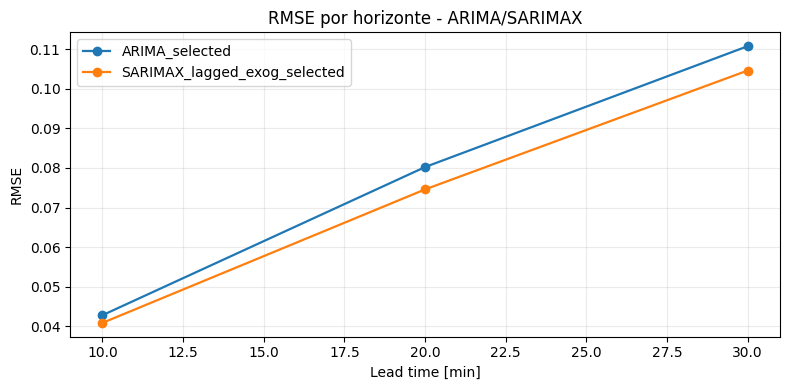

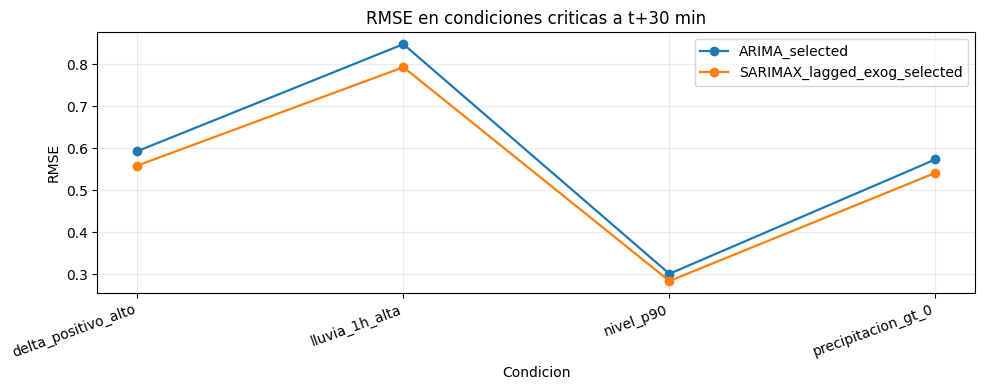

In [19]:
plot_df = lead_metrics_df[lead_metrics_df["segmento"] == "global"].copy()

fig, ax = plt.subplots(figsize=(8, 4))
for model_name, model_df in plot_df.groupby("modelo"):
    model_df = model_df.sort_values("lead_minutes")
    ax.plot(model_df["lead_minutes"], model_df["RMSE"], marker="o", linewidth=1.6, label=model_name)

ax.set_title("RMSE por horizonte - ARIMA/SARIMAX")
ax.set_xlabel("Lead time [min]")
ax.set_ylabel("RMSE")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "02_rmse_por_lead_global.png"), dpi=180, bbox_inches="tight")
plt.show()


condition_t30 = condition_lead_metrics_df[
    (condition_lead_metrics_df["segmento"] == "global")
    & (condition_lead_metrics_df["lead_minutes"] == 30)
    & (condition_lead_metrics_df["condicion"] != "todos")
].copy()

fig, ax = plt.subplots(figsize=(10, 4))
for model_name, model_df in condition_t30.groupby("modelo"):
    ax.plot(model_df["condicion"], model_df["RMSE"], marker="o", linewidth=1.6, label=model_name)

ax.set_title("RMSE en condiciones criticas a t+30 min")
ax.set_xlabel("Condicion")
ax.set_ylabel("RMSE")
ax.grid(alpha=0.25)
ax.legend()
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "03_rmse_condiciones_t30.png"), dpi=180, bbox_inches="tight")
plt.show()


## Archivos generados

Al finalizar la ejecucion, los resultados quedan guardados en:

```text
reports/17_arima_sarimax_baselines/
```

Archivos principales:

| Archivo | Contenido |
|---|---|
| `17_dataset_resumen.csv` | Resumen de segmentos cargados. |
| `17_split_resumen.csv` | Split train/validation/test por segmento. |
| `17_validacion_ordenes.csv` | Metricas de validacion para cada orden ARIMA/SARIMAX probado. |
| `17_modelos_seleccionados.csv` | Orden seleccionado por familia y segmento. |
| `17_predicciones_test_long.csv` | Todas las predicciones sobre test en formato largo. |
| `17_metricas_global_segmento.csv` | Metricas globales y por segmento sobre test. |
| `17_metricas_por_lead.csv` | Metricas por horizonte de 10, 20 y 30 minutos. |
| `17_metricas_condiciones.csv` | Metricas agregadas por condicion critica. |
| `17_metricas_condiciones_por_lead.csv` | Metricas por condicion critica y lead time. |

Estos CSV permiten analizar los resultados sin volver a ejecutar el ajuste de modelos estadisticos.
